# Understanding RNN cell and RNN layer

In [1]:
##RNN Cell
import torch
import torch.nn as nn

# A single RNN cell
rnn_cell = nn.RNNCell(input_size=1, hidden_size=1)

# Simple sequence (e.g., time series data)
sequence = torch.tensor([[1], [2], [3], [4]], dtype=torch.float)

# Initial hidden state (usually zeros)
hidden_state = torch.tensor([[0]], dtype=torch.float)
print("Initial Hidden State ", hidden_state)

for i, input in enumerate(sequence):
    hidden_state = rnn_cell(input, hidden_state)
    print(f"Time step {i}: Input {input.item()}, Hidden state {hidden_state.item()}")

Initial Hidden State  tensor([[0.]])
Time step 0: Input 1.0, Hidden state 0.787653386592865
Time step 1: Input 2.0, Hidden state 0.8703098893165588
Time step 2: Input 3.0, Hidden state 0.8078088164329529
Time step 3: Input 4.0, Hidden state 0.6682732105255127


# RNN layer

In [2]:
# A simple RNN layer
rnn_layer = nn.RNN(input_size=1, hidden_size=1, batch_first=True)

# The same sequence but batched (batch_size, seq_len, input_size)
sequence_batched = sequence.view(1, -1, 1)

In [3]:
def generate_even_numbers(start, end):
    return [i for i in range(start, end if end % 2 == 0 else end + 1, 2)]

In [4]:
def normalize_data(data):
    max_val = max(data)
    return [x / max_val for x in data]

In [5]:
def create_sequences(data, seq_length):
    xs, ys = [], []

    for i in range(len(data) - seq_length):
        x = data[i:i + seq_length]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)

    return torch.tensor(xs, dtype=torch.float32), torch.tensor(ys, dtype=torch.float32)

In [6]:
seq_length = 20
data = generate_even_numbers(0, 1000)
normalized_data = normalize_data(data)
X, y = create_sequences(normalized_data, seq_length)
X = X.unsqueeze(-1)  # Adding feature dimension

In [7]:
from torch.utils.data import DataLoader, TensorDataset

# DataLoader
batch_size = 1
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

In [8]:
class SimpleRNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(SimpleRNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden):
        out, hidden = self.rnn(x, hidden)
        out = self.linear(out[:, -1, :])  # Take the output of the last time step
        return out, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleRNNModel(input_size=X.shape[2], hidden_size=64, output_size=1, num_layers=1).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
num_epochs = 100
epoch_losses = []

for epoch in range(num_epochs):
    total_loss = 0

    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        hidden = model.init_hidden(batch_size).to(device)
        optimizer.zero_grad()
        output, hidden = model(x_batch, hidden)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    epoch_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f'Epoch {epoch} loss: {avg_loss}')

/home/dream/.virtualenvs/LLM/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0 loss: 0.012116371544794868
Epoch 10 loss: 0.00025356396497675204
Epoch 20 loss: 8.927690462363635e-05
Epoch 30 loss: 3.773000949869436e-06
Epoch 40 loss: 1.587350423744562e-05
Epoch 50 loss: 3.844151866759515e-06
Epoch 60 loss: 3.01943404584875e-05
Epoch 70 loss: 3.661762962290001e-05
Epoch 80 loss: 1.0623420150325524e-05
Epoch 90 loss: 1.3496746746841902e-05


In [11]:
model.eval()

with torch.no_grad():
    test_seq = X[-1].unsqueeze(0).repeat(batch_size, 1, 1).to(device)
    hidden = model.init_hidden(batch_size).to(device)
    predicted, _ = model(test_seq, hidden)
    predicted_next_number = (predicted[0].item() * max(data))  # Denormalize
    actual_next_number = data[-1]
    print(f'Actual next number: {actual_next_number}')
    print(f'Predicted next number: {predicted_next_number}')

Actual next number: 998
Predicted next number: 996.7740051746368


# Working example: Language modeling

In [12]:
# Define a simple LSTM model
class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(SimpleLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size)

    def forward(self, input_seq):
        outputs, (hidden, cell) = self.lstm(input_seq)
        return outputs, hidden, cell


# Initialize the model
input_size = 1
hidden_size = 1
model = SimpleLSTM(input_size, hidden_size)

# Create a simple sequence and reshape it to [sequence_length, batch_size, input_size]
sequence = torch.tensor([[[0.1]], [[0.2]], [[0.3]]])

# Pass the sequence through the model and print context vectors
with torch.no_grad():
    outputs, hidden, cell = model(sequence)
    print("Outputs of each step: ", outputs)
    print("Final hidden state: ", hidden)
    print("Final cell state: ", cell)

Outputs of each step:  tensor([[[0.1523]],

        [[0.1922]],

        [[0.2108]]])
Final hidden state:  tensor([[[0.2108]]])
Final cell state:  tensor([[[0.4709]]])


# Visualizing last two years’ data for reliance

[*********************100%***********************]  1 of 1 completed


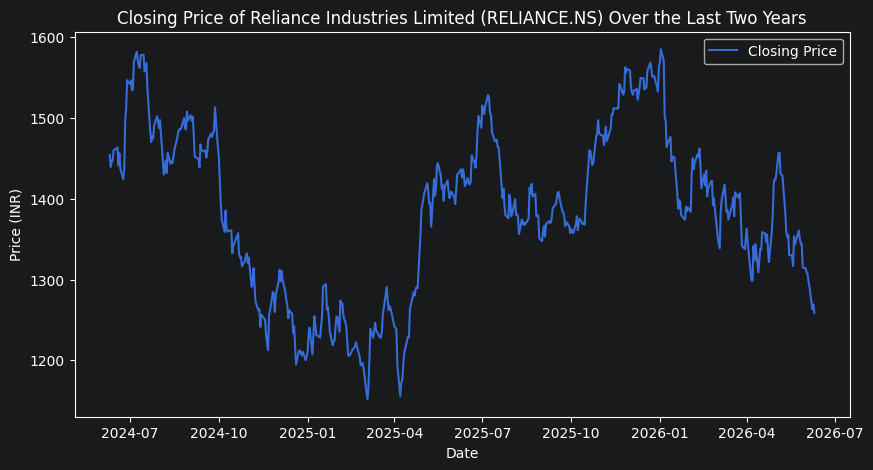

In [13]:
from matplotlib import pyplot as plt
import yfinance as yf
import pandas as pd

# Ticker symbol for Reliance Industries Limited
stock_symbol = 'RELIANCE.NS'

# Dates for the past two years
end_date = pd.Timestamp.now()
start_date = end_date - pd.DateOffset(years=2)

# Downloading the data
data = yf.download(stock_symbol, start=start_date, end=end_date)
plt.figure(figsize=(10, 5))
plt.plot(data['Close'], label='Closing Price')
plt.title('Closing Price of Reliance Industries Limited (RELIANCE.NS) Over the Last Two Years')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

# LSTM for stock prediction

In [14]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from torch.autograd import Variable
import matplotlib.pyplot as plt

In [15]:
data = pd.read_csv('reliance_stock_data.csv')
prices = data['Close'].values.reshape(-1, 1)
scaler = MinMaxScaler()
prices = scaler.fit_transform(prices)

In [16]:
sequence_length = 30
hidden_size = 100
num_layers = 3
num_epochs = 100
batch_size = 16
learning_rate = 0.001
input_size = 1
output_size = 1
dropout_prob = 0.3

In [17]:
def create_sequences(data, seq_length):
    xs, ys = [], []

    for i in range(len(data) - seq_length - 1):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)

    return np.array(xs), np.array(ys)

In [18]:
train_size = int(len(prices) * 0.8)
test_size = len(prices) - train_size
train_data, test_data = prices[0:train_size, :], prices[train_size:len(prices), :]
x_train, y_train = create_sequences(train_data, sequence_length)
x_test, y_test = create_sequences(test_data, sequence_length)

In [19]:
x_train = torch.tensor(x_train).float()
y_train = torch.tensor(y_train).float()
x_test = torch.tensor(x_test).float()
y_test = torch.tensor(y_test).float()

In [20]:
class EnhancedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_prob=0.5):
        super(EnhancedLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout_prob)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [21]:
enhanced_model = EnhancedLSTM(input_size, hidden_size, num_layers, output_size, dropout_prob)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(enhanced_model.parameters(), lr=learning_rate)

In [22]:
for epoch in range(num_epochs):
    enhanced_model.train()
    outputs = enhanced_model(x_train)
    optimizer.zero_grad()
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/100], Loss: nan
Epoch [11/100], Loss: nan
Epoch [21/100], Loss: nan
Epoch [31/100], Loss: nan
Epoch [41/100], Loss: nan
Epoch [51/100], Loss: nan
Epoch [61/100], Loss: nan
Epoch [71/100], Loss: nan
Epoch [81/100], Loss: nan
Epoch [91/100], Loss: nan


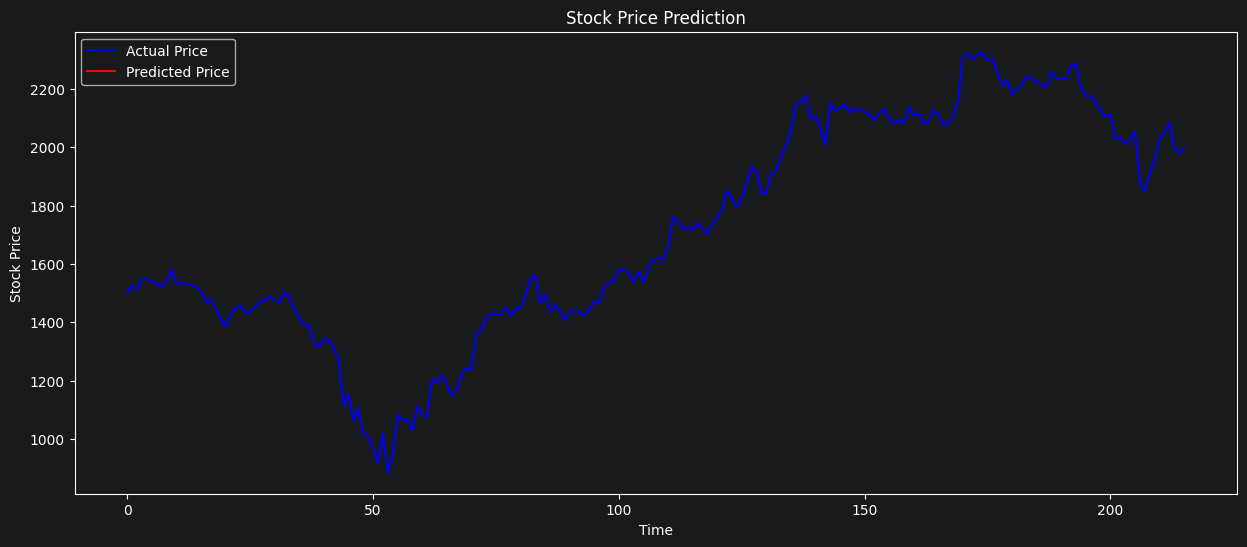

In [23]:
enhanced_model.eval()
test_predict = enhanced_model(x_test)
test_predict = scaler.inverse_transform(test_predict.detach().numpy())
y_test = scaler.inverse_transform(y_test.detach().numpy())
plt.figure(figsize=(15, 6))
plt.plot(y_test, label='Actual Price', color='blue')
plt.plot(test_predict, label='Predicted Price', color='red')
plt.title('Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()